# AI-Based Agricultural Price Forecasting: Comprehensive Analysis

**Project:** AI Market Trend Analyzer  
**Dataset:** Onion Prices (India) - 2022 to 2025  
**Objective:** Forecast 2026 Agricultural Product Prices Using Machine Learning and LSTM  

---

## Table of Contents
1. [Problem Definition & Objective](#1-problem-definition--objective)
2. [Data Understanding & Preparation](#2-data-understanding--preparation)
3. [Model / System Design](#3-model--system-design)
4. [Core Implementation](#4-core-implementation)
5. [Evaluation & Analysis](#5-evaluation--analysis)

---

## 1. Problem Definition & Objective

### 1.1 Background and Motivation

Agricultural commodity prices, particularly for essential vegetables like onions, exhibit significant volatility due to multiple factors including:
- **Seasonal variations** (harvest cycles, weather patterns)
- **Supply chain disruptions** (transportation, storage)
- **Market dynamics** (demand fluctuations, promotional activities)
- **External shocks** (policy changes, extreme weather events)

Accurate price forecasting is crucial for:
- **Farmers:** Planning cultivation and harvest schedules
- **Traders:** Optimizing inventory and pricing strategies
- **Policymakers:** Implementing timely market interventions
- **Consumers:** Understanding price trends and budgeting

### 1.2 Problem Statement

**Objective:** Develop a robust machine learning system to forecast onion prices in India for the year 2026 based on historical data from 2022-2025.

**Challenges:**
- Non-linear price patterns with multiple seasonality components
- Temporal dependencies requiring sequence modeling
- Balancing model complexity with interpretability

### 1.3 Approach

We implement and compare three distinct modeling approaches:
1. **Linear Regression** - Baseline model for linear trend analysis
2. **Random Forest** - Ensemble method for capturing non-linear relationships
3. **LSTM (Long Short-Term Memory)** - Deep learning for temporal sequence modeling

### 1.4 Dataset Overview

- **Product:** Onion prices in India
- **Time Period:** January 2022 to December 2025 (4 years)
- **Granularity:** Daily observations
- **Key Features:** Price (₹/kg), Volume (quintals), Promotional flags, Temporal features
- **Target Variable:** `price_rupees_per_kg`

## 2. Data Understanding & Preparation

### 2.1 Import Libraries and Modules

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
import sys
import os

# Add src directory to path
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'src'))

# Import custom modules
from data_generator import generate_onion_price_data, save_dataset
from feature_engineering import (
    create_lag_features,
    create_rolling_features,
    create_cyclical_features,
    engineer_all_features,
    prepare_train_test_split,
    create_sequences
)
from model_utils import (
    calculate_metrics,
    plot_predictions,
    plot_residuals,
    plot_feature_importance,
    print_metrics
)

# Machine Learning libraries
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Deep Learning libraries
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("✅ All libraries and modules imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"TensorFlow/Keras version: {keras.__version__}")

✅ All libraries and modules imported successfully!
NumPy version: 2.3.5
Pandas version: 2.3.3
TensorFlow/Keras version: 3.12.0


### 2.2 Load Dataset

In [2]:
# Load the synthetic onion price dataset
data_path = os.path.join(os.path.dirname(os.getcwd()), 'data', 'onion_prices_synthetic.csv')
df = pd.read_csv(data_path)
df['date'] = pd.to_datetime(df['date'])

print("="*80)
print("DATASET LOADED SUCCESSFULLY")
print("="*80)
print(f"\nDataset Shape: {df.shape}")
print(f"Date Range: {df['date'].min().strftime('%Y-%m-%d')} to {df['date'].max().strftime('%Y-%m-%d')}")
print(f"Total Days: {len(df)}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nData Types:\n{df.dtypes}")

DATASET LOADED SUCCESSFULLY

Dataset Shape: (1461, 9)
Date Range: 2022-01-01 to 2025-12-31
Total Days: 1461

Columns: ['date', 'price_rupees_per_kg', 'volume_quintals', 'promo_flag', 'year', 'month', 'day_of_week', 'day_of_year', 'week_of_year']

Data Types:
date                   datetime64[ns]
price_rupees_per_kg           float64
volume_quintals               float64
promo_flag                      int64
year                            int64
month                           int64
day_of_week                     int64
day_of_year                     int64
week_of_year                    int64
dtype: object


### 2.3 Exploratory Data Analysis

In [3]:
# Display first few rows
print("\nFirst 10 rows of the dataset:")
display(df.head(10))

# Statistical summary
print("\nStatistical Summary:")
display(df.describe())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())


First 10 rows of the dataset:


,date,price_rupees_per_kg,volume_quintals,promo_flag,year,month,day_of_week,day_of_year,week_of_year
0,2022-01-01,29.91,5558.83,0,2022,1,5,1,52
1,2022-01-02,31.77,5163.28,0,2022,1,6,2,52
2,2022-01-03,33.83,5464.17,0,2022,1,0,3,1
3,2022-01-04,34.32,4972.38,0,2022,1,1,4,1
4,2022-01-05,33.50,4933.86,0,2022,1,2,5,1
5,2022-01-06,34.85,5015.68,0,2022,1,3,6,1
6,2022-01-07,31.87,5187.07,0,2022,1,4,7,1
7,2022-01-08,30.93,5004.75,0,2022,1,5,8,1
8,2022-01-09,30.39,5081.79,0,2022,1,6,9,1
9,2022-01-10,30.79,4842.33,0,2022,1,0,10,2



Statistical Summary:


,date,price_rupees_per_kg,volume_quintals,promo_flag,year,month,day_of_week,day_of_year,week_of_year
count,1461,1461.000000,1461.000000,1461.000000,1461.000000,1461.000000,1461.000000,1461.000000,1461.000000
mean,2024-01-01 00:00:00,39.854586,4876.216256,0.091034,2023.500342,6.522930,2.999316,183.125257,26.482546
min,2022-01-01 00:00:00,24.510000,3238.810000,0.000000,2022.000000,1.000000,0.000000,1.000000,1.000000
25%,2023-01-01 00:00:00,35.420000,4501.140000,0.000000,2023.000000,4.000000,1.000000,92.000000,13.000000
50%,2024-01-01 00:00:00,39.380000,4802.820000,0.000000,2024.000000,7.000000,3.000000,183.000000,26.000000
75%,2024-12-31 00:00:00,43.390000,5140.500000,0.000000,2024.000000,10.000000,5.000000,274.000000,40.000000
max,2025-12-31 00:00:00,65.050000,7737.920000,1.000000,2025.000000,12.000000,6.000000,366.000000,52.000000
std,NaN,6.223087,597.398382,0.287755,1.118111,3.449884,2.001883,105.474746,15.061854



Missing Values:
date                   0
price_rupees_per_kg    0
volume_quintals        0
promo_flag             0
year                   0
month                  0
day_of_week            0
day_of_year            0
week_of_year           0
dtype: int64


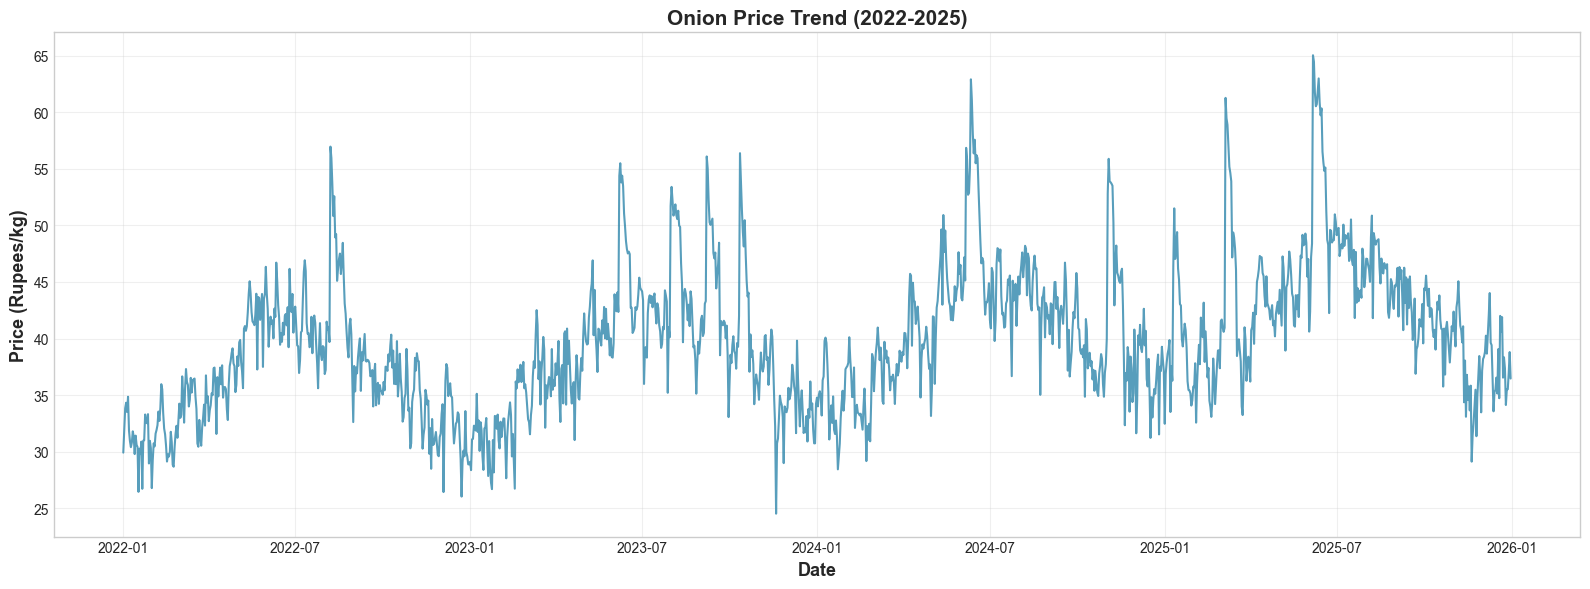

Average Price: ₹39.85/kg
Min Price: ₹24.51/kg
Max Price: ₹65.05/kg
Standard Deviation: ₹6.22/kg


In [4]:
# Visualize price trend over time
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df['date'], df['price_rupees_per_kg'], linewidth=1.5, color='#2E86AB', alpha=0.8)
ax.set_xlabel('Date', fontsize=13, fontweight='bold')
ax.set_ylabel('Price (Rupees/kg)', fontsize=13, fontweight='bold')
ax.set_title('Onion Price Trend (2022-2025)', fontsize=15, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Average Price: ₹{df['price_rupees_per_kg'].mean():.2f}/kg")
print(f"Min Price: ₹{df['price_rupees_per_kg'].min():.2f}/kg")
print(f"Max Price: ₹{df['price_rupees_per_kg'].max():.2f}/kg")
print(f"Standard Deviation: ₹{df['price_rupees_per_kg'].std():.2f}/kg")

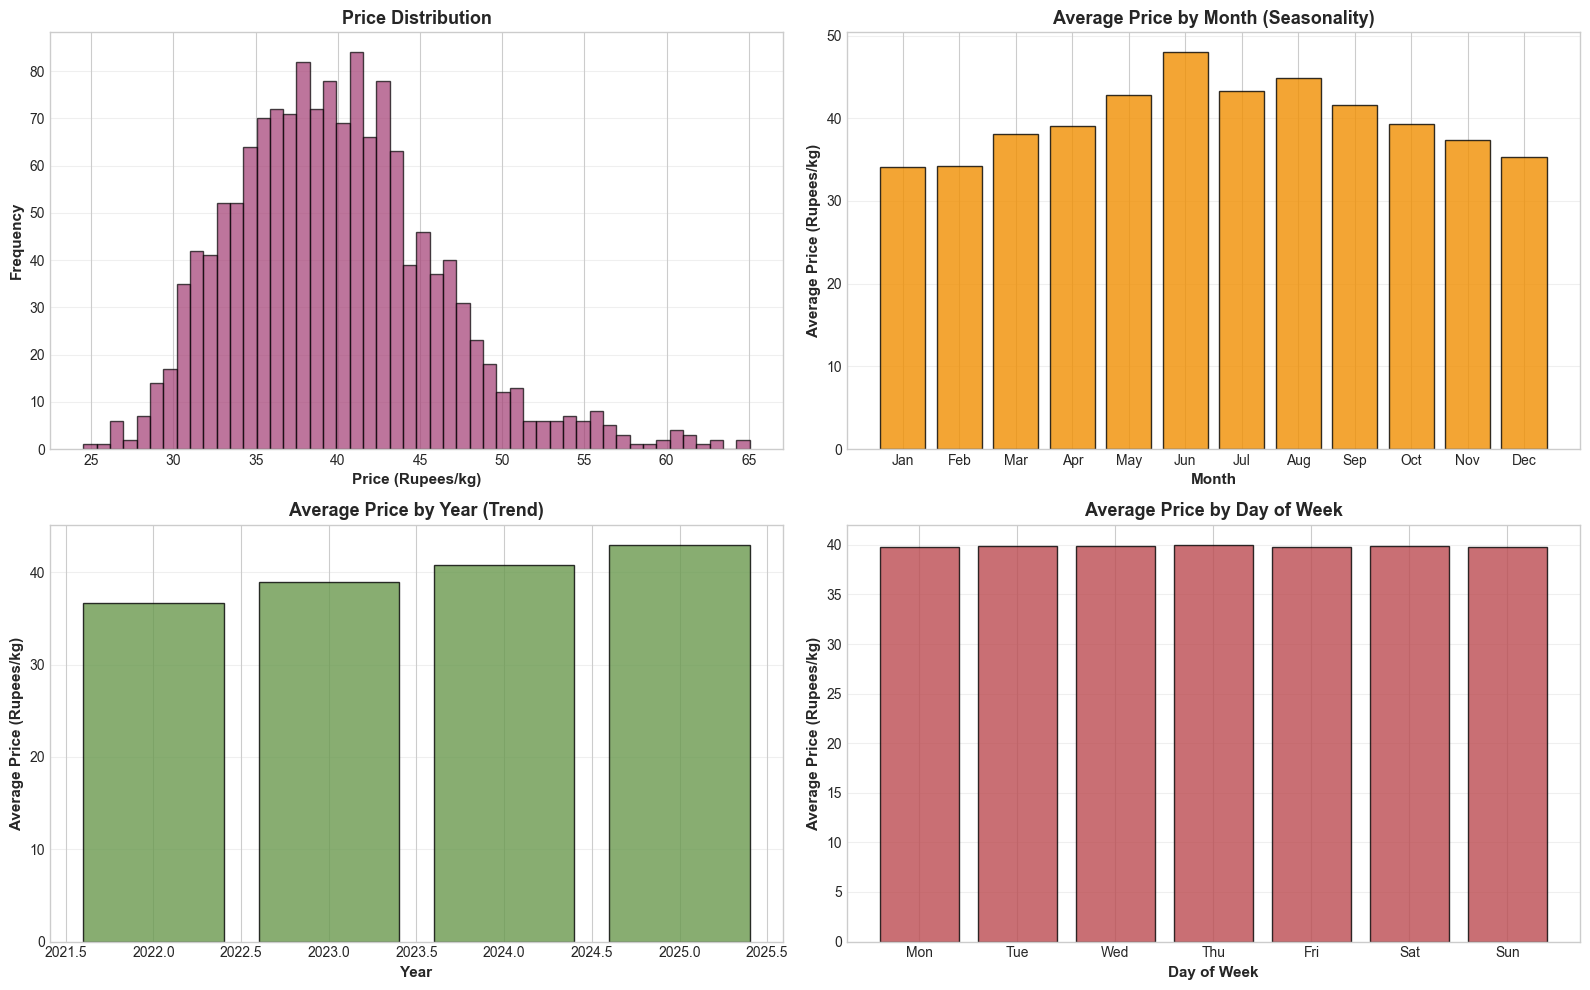

In [5]:
# Distribution and seasonality analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Price distribution
axes[0, 0].hist(df['price_rupees_per_kg'], bins=50, edgecolor='black', alpha=0.7, color='#A23B72')
axes[0, 0].set_xlabel('Price (Rupees/kg)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Price Distribution', fontsize=13, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Monthly average prices
monthly_avg = df.groupby('month')['price_rupees_per_kg'].mean()
axes[0, 1].bar(monthly_avg.index, monthly_avg.values, color='#F18F01', alpha=0.8, edgecolor='black')
axes[0, 1].set_xlabel('Month', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Average Price (Rupees/kg)', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Average Price by Month (Seasonality)', fontsize=13, fontweight='bold')
axes[0, 1].set_xticks(range(1, 13))
axes[0, 1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Yearly comparison
yearly_avg = df.groupby('year')['price_rupees_per_kg'].mean()
axes[1, 0].bar(yearly_avg.index, yearly_avg.values, color='#6A994E', alpha=0.8, edgecolor='black')
axes[1, 0].set_xlabel('Year', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Average Price (Rupees/kg)', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Average Price by Year (Trend)', fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Day of week analysis
dow_avg = df.groupby('day_of_week')['price_rupees_per_kg'].mean()
axes[1, 1].bar(dow_avg.index, dow_avg.values, color='#BC4B51', alpha=0.8, edgecolor='black')
axes[1, 1].set_xlabel('Day of Week', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Average Price (Rupees/kg)', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Average Price by Day of Week', fontsize=13, fontweight='bold')
axes[1, 1].set_xticks(range(7))
axes[1, 1].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 2.4 Feature Engineering

We apply comprehensive feature engineering to capture temporal patterns:

1. **Lag Features:** Previous day, week, and month prices (captures autoregressive patterns)
2. **Rolling Statistics:** 7-day and 30-day moving averages and standard deviations (captures trends and volatility)
3. **Cyclical Features:** Sin/cos transformations of month, day of week, and day of year (captures seasonality)

In [6]:
# Apply feature engineering using existing module
print("Applying feature engineering...")
df_engineered = engineer_all_features(df)

print(f"\nOriginal features: {df.shape[1]}")
print(f"Engineered features: {df_engineered.shape[1]}")
print(f"New features added: {df_engineered.shape[1] - df.shape[1]}")
print(f"\nRows before: {df.shape[0]}")
print(f"Rows after (NaN dropped): {df_engineered.shape[0]}")
print(f"\nNew feature columns:")
new_cols = [col for col in df_engineered.columns if col not in df.columns]
for col in new_cols:
    print(f"  - {col}")

Applying feature engineering...

Original features: 9
Engineered features: 22
New features added: 13

Rows before: 1461
Rows after (NaN dropped): 1431

New feature columns:
  - price_rupees_per_kg_lag_1
  - price_rupees_per_kg_lag_7
  - price_rupees_per_kg_lag_30
  - price_rupees_per_kg_rolling_mean_7
  - price_rupees_per_kg_rolling_std_7
  - price_rupees_per_kg_rolling_mean_30
  - price_rupees_per_kg_rolling_std_30
  - month_sin
  - month_cos
  - day_of_week_sin
  - day_of_week_cos
  - day_of_year_sin
  - day_of_year_cos


In [7]:
# Display sample of engineered features
print("\nSample of engineered features:")
display(df_engineered[['date', 'price_rupees_per_kg', 'price_rupees_per_kg_lag_1', 
                        'price_rupees_per_kg_lag_7', 'price_rupees_per_kg_rolling_mean_7',
                        'month_sin', 'month_cos']].head(10))


Sample of engineered features:


,date,price_rupees_per_kg,price_rupees_per_kg_lag_1,price_rupees_per_kg_lag_7,price_rupees_per_kg_rolling_mean_7,month_sin,month_cos
30,2022-01-31,26.77,30.31,33.28,30.765714,0.500000,0.866025
31,2022-02-01,29.24,26.77,32.56,30.291429,0.866025,0.500000
32,2022-02-02,30.73,29.24,32.51,30.037143,0.866025,0.500000
33,2022-02-03,30.46,30.73,33.31,29.630000,0.866025,0.500000
34,2022-02-04,31.59,30.46,28.95,30.007143,0.866025,0.500000
35,2022-02-05,31.91,31.59,30.95,30.144286,0.866025,0.500000
36,2022-02-06,32.34,31.91,30.31,30.434286,0.866025,0.500000
37,2022-02-07,33.54,32.34,26.77,31.401429,0.866025,0.500000
38,2022-02-08,32.71,33.54,29.24,31.897143,0.866025,0.500000
39,2022-02-09,33.85,32.71,30.73,32.342857,0.866025,0.500000


### 2.5 Train-Test Split

We use a temporal split strategy:
- **Training Set:** 2022-2024 (3 years)
- **Test Set:** 2025 (1 year)

This ensures the model is evaluated on future unseen data, simulating real-world forecasting scenarios.

In [8]:
# Prepare train-test split (2025 as test year)
train_df, test_df = prepare_train_test_split(df_engineered, test_year=2025)

print("="*80)
print("TRAIN-TEST SPLIT")
print("="*80)
print(f"\nTraining Set:")
print(f"  - Years: {train_df['year'].min()} to {train_df['year'].max()}")
print(f"  - Samples: {len(train_df)}")
print(f"  - Date Range: {train_df['date'].min().strftime('%Y-%m-%d')} to {train_df['date'].max().strftime('%Y-%m-%d')}")

print(f"\nTest Set:")
print(f"  - Year: {test_df['year'].unique()[0]}")
print(f"  - Samples: {len(test_df)}")
print(f"  - Date Range: {test_df['date'].min().strftime('%Y-%m-%d')} to {test_df['date'].max().strftime('%Y-%m-%d')}")

print(f"\nTrain/Test Ratio: {len(train_df)/len(test_df):.2f}")

TRAIN-TEST SPLIT

Training Set:
  - Years: 2022 to 2024
  - Samples: 1066
  - Date Range: 2022-01-31 to 2024-12-31

Test Set:
  - Year: 2025
  - Samples: 365
  - Date Range: 2025-01-01 to 2025-12-31

Train/Test Ratio: 2.92


## 3. Model / System Design

### 3.1 Machine Learning Pipeline Architecture

Our forecasting system follows a modular pipeline:

```
Raw Data → Feature Engineering → Model Training → Prediction → Evaluation
```

**Key Design Decisions:**

1. **Modular Architecture:** Separate modules for data generation, feature engineering, and model utilities
2. **Multiple Models:** Compare baseline (Linear Regression), ensemble (Random Forest), and deep learning (LSTM)
3. **Temporal Features:** Capture seasonality, trends, and autoregressive patterns
4. **Scalability:** Design supports easy addition of new features and models

### 3.2 Feature Selection Strategy

**Excluded Features:**
- `date` (used for indexing, not prediction)
- `price_rupees_per_kg` (target variable)
- `year`, `month`, `day_of_week`, `day_of_year`, `week_of_year` (replaced by cyclical encodings)

**Included Features:**
- Volume, promotional flags
- Lag features (1, 7, 30 days)
- Rolling statistics (7, 30 days)
- Cyclical encodings (sin/cos transformations)

### 3.3 Model Selection Rationale

| Model | Strengths | Use Case |
|-------|-----------|----------|
| **Linear Regression** | Simple, interpretable, fast | Baseline for linear trends |
| **Random Forest** | Handles non-linearity, feature importance | Captures complex patterns |
| **LSTM** | Temporal dependencies, sequence learning | Deep temporal modeling |

### 3.4 Evaluation Metrics

- **RMSE (Root Mean Squared Error):** Penalizes large errors, same units as target
- **MAE (Mean Absolute Error):** Average absolute deviation, robust to outliers
- **R² Score:** Proportion of variance explained (0-1, higher is better)

## 4. Core Implementation

### 4.1 Prepare Features and Target

In [9]:
# Define features to exclude
exclude_cols = ['date', 'price_rupees_per_kg', 'year', 'month', 'day_of_week', 'day_of_year', 'week_of_year']

# Prepare features and target for ML models
feature_cols = [col for col in train_df.columns if col not in exclude_cols]

X_train = train_df[feature_cols].values
y_train = train_df['price_rupees_per_kg'].values

X_test = test_df[feature_cols].values
y_test = test_df['price_rupees_per_kg'].values

print("="*80)
print("FEATURE PREPARATION")
print("="*80)
print(f"\nNumber of features: {len(feature_cols)}")
print(f"\nFeature list:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")

print(f"\nTraining set shape: X={X_train.shape}, y={y_train.shape}")
print(f"Test set shape: X={X_test.shape}, y={y_test.shape}")

FEATURE PREPARATION

Number of features: 15

Feature list:
   1. volume_quintals
   2. promo_flag
   3. price_rupees_per_kg_lag_1
   4. price_rupees_per_kg_lag_7
   5. price_rupees_per_kg_lag_30
   6. price_rupees_per_kg_rolling_mean_7
   7. price_rupees_per_kg_rolling_std_7
   8. price_rupees_per_kg_rolling_mean_30
   9. price_rupees_per_kg_rolling_std_30
  10. month_sin
  11. month_cos
  12. day_of_week_sin
  13. day_of_week_cos
  14. day_of_year_sin
  15. day_of_year_cos

Training set shape: X=(1066, 15), y=(1066,)
Test set shape: X=(365, 15), y=(365,)


### 4.2 Model 1: Linear Regression (Baseline)

Linear Regression serves as our baseline model. It assumes a linear relationship between features and the target variable.

In [10]:
print("\n" + "="*80)
print("TRAINING LINEAR REGRESSION MODEL")
print("="*80)

# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predictions
y_train_pred_lr = lr_model.predict(X_train)
y_test_pred_lr = lr_model.predict(X_test)

# Calculate metrics
train_metrics_lr = calculate_metrics(y_train, y_train_pred_lr)
test_metrics_lr = calculate_metrics(y_test, y_test_pred_lr)

# Print metrics
print_metrics(train_metrics_lr, "Linear Regression - Train")
print_metrics(test_metrics_lr, "Linear Regression - Test")

print("✅ Linear Regression trained successfully!")


TRAINING LINEAR REGRESSION MODEL

Linear Regression - Train Performance Metrics
RMSE           : 1.9152
MAE            : 1.4332
R2             : 0.8926


Linear Regression - Test Performance Metrics
RMSE           : 2.1451
MAE            : 1.5377
R2             : 0.8748

✅ Linear Regression trained successfully!


### 4.3 Model 2: Random Forest Regressor

Random Forest is an ensemble method that builds multiple decision trees and averages their predictions. It can capture non-linear relationships and provides feature importance.

In [11]:
print("\n" + "="*80)
print("TRAINING RANDOM FOREST MODEL")
print("="*80)

# Train Random Forest
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

print("Training Random Forest (this may take a moment...)")
rf_model.fit(X_train, y_train)

# Predictions
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

# Calculate metrics
train_metrics_rf = calculate_metrics(y_train, y_train_pred_rf)
test_metrics_rf = calculate_metrics(y_test, y_test_pred_rf)

# Print metrics
print_metrics(train_metrics_rf, "Random Forest - Train")
print_metrics(test_metrics_rf, "Random Forest - Test")

print("✅ Random Forest trained successfully!")


TRAINING RANDOM FOREST MODEL
Training Random Forest (this may take a moment...)

Random Forest - Train Performance Metrics
RMSE           : 0.9060
MAE            : 0.6523
R2             : 0.9760


Random Forest - Test Performance Metrics
RMSE           : 2.4343
MAE            : 1.7928
R2             : 0.8388

✅ Random Forest trained successfully!


### 4.4 Model 3: LSTM (Long Short-Term Memory)

LSTM is a type of recurrent neural network designed to learn temporal dependencies in sequential data. It's particularly effective for time series forecasting.

In [12]:
print("\n" + "="*80)
print("PREPARING DATA FOR LSTM MODEL")
print("="*80)

# Scale features for LSTM
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

# Create sequences for LSTM (lookback = 30 days)
lookback = 30
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, lookback=lookback)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, lookback=lookback)

print(f"\nLookback window: {lookback} days")
print(f"Training sequences: {X_train_seq.shape}")
print(f"Test sequences: {X_test_seq.shape}")
print(f"Features per timestep: {X_train_seq.shape[2]}")


PREPARING DATA FOR LSTM MODEL

Lookback window: 30 days
Training sequences: (1036, 30, 15)
Test sequences: (335, 30, 15)
Features per timestep: 15


In [13]:
print("\n" + "="*80)
print("BUILDING AND TRAINING LSTM MODEL")
print("="*80)

# Build LSTM model
lstm_model = Sequential([
    LSTM(64, activation='relu', return_sequences=True, input_shape=(lookback, X_train_seq.shape[2])),
    Dropout(0.2),
    LSTM(32, activation='relu', return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

print("\nModel Architecture:")
lstm_model.summary()

# Early stopping callback
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train LSTM
print("\nTraining LSTM (this may take a few minutes...)")
history = lstm_model.fit(
    X_train_seq, y_train_seq,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

print("\n✅ LSTM trained successfully!")


BUILDING AND TRAINING LSTM MODEL

Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 30, 64)              │          20,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 30, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 33,441 (130.63 KB)

 Trainable params: 33,441 (130.63 KB)

 Non-trainable params: 0 (0.00 B)


Training LSTM (this may take a few minutes...)
Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - loss: 0.0454 - mae: 0.1605 - val_loss: 0.0210 - val_mae: 0.1014
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0134 - mae: 0.0854 - val_loss: 0.0179 - val_mae: 0.0943
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0124 - mae: 0.0826 - val_loss: 0.0168 - val_mae: 0.0880
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0109 - mae: 0.0770 - val_loss: 0.0158 - val_mae: 0.0854
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0108 - mae: 0.0757 - val_loss: 0.0168 - val_mae: 0.0884
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0107 - mae: 0.0756 - val_loss: 0.0193 - val_mae: 0.0963
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0098 - mae: 0.0738 - val_loss: 0.0162 - val_mae: 0.0884
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0095 - mae: 0.0730 - val_loss: 0.0152 - val_mae: 0.0856
Epoch 9/50
26/26

In [14]:
# LSTM Predictions
y_train_pred_lstm_scaled = lstm_model.predict(X_train_seq, verbose=0).flatten()
y_test_pred_lstm_scaled = lstm_model.predict(X_test_seq, verbose=0).flatten()

# Inverse transform predictions
y_train_pred_lstm = scaler_y.inverse_transform(y_train_pred_lstm_scaled.reshape(-1, 1)).flatten()
y_test_pred_lstm = scaler_y.inverse_transform(y_test_pred_lstm_scaled.reshape(-1, 1)).flatten()

# Calculate metrics (align with sequence length)
train_metrics_lstm = calculate_metrics(y_train_seq, y_train_pred_lstm_scaled)
test_metrics_lstm = calculate_metrics(y_test_seq, y_test_pred_lstm_scaled)

# Print metrics
print_metrics(train_metrics_lstm, "LSTM - Train")
print_metrics(test_metrics_lstm, "LSTM - Test")


LSTM - Train Performance Metrics
RMSE           : 0.0861
MAE            : 0.0630
R2             : 0.6720


LSTM - Test Performance Metrics
RMSE           : 0.1148
MAE            : 0.0807
R2             : 0.4749



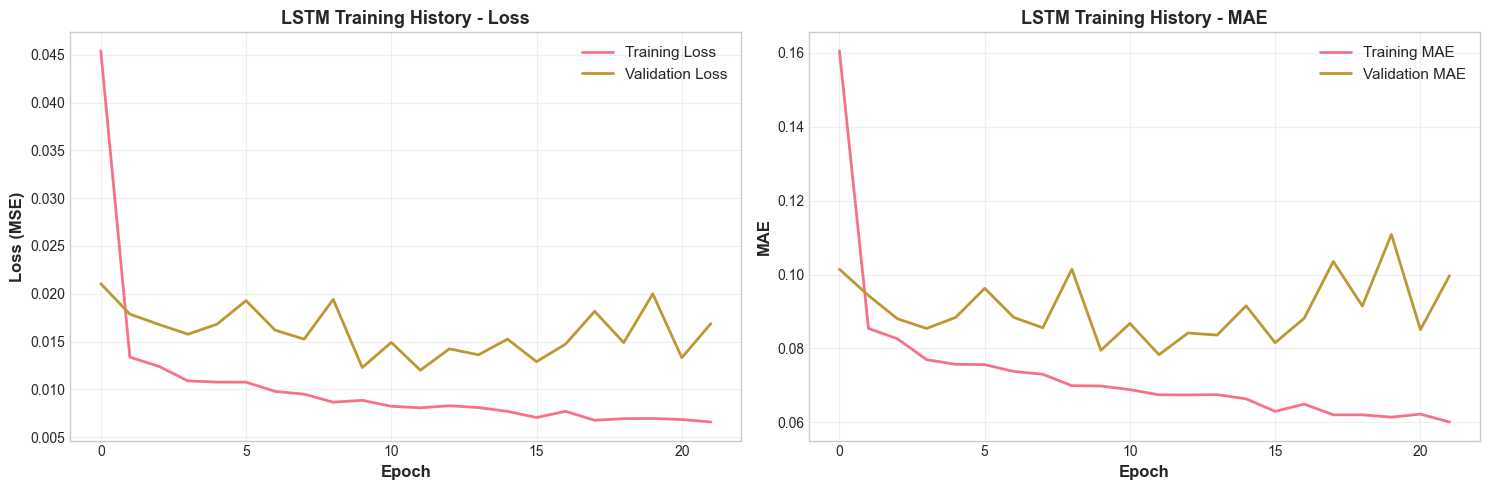

In [15]:
# Plot LSTM training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Loss (MSE)', fontsize=12, fontweight='bold')
axes[0].set_title('LSTM Training History - Loss', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# MAE
axes[1].plot(history.history['mae'], label='Training MAE', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1].set_ylabel('MAE', fontsize=12, fontweight='bold')
axes[1].set_title('LSTM Training History - MAE', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Evaluation & Analysis

### 5.1 Model Comparison

In [16]:
# Create comprehensive comparison table
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'LSTM'],
    'Train_RMSE': [train_metrics_lr['RMSE'], train_metrics_rf['RMSE'], train_metrics_lstm['RMSE']],
    'Test_RMSE': [test_metrics_lr['RMSE'], test_metrics_rf['RMSE'], test_metrics_lstm['RMSE']],
    'Train_MAE': [train_metrics_lr['MAE'], train_metrics_rf['MAE'], train_metrics_lstm['MAE']],
    'Test_MAE': [test_metrics_lr['MAE'], test_metrics_rf['MAE'], test_metrics_lstm['MAE']],
    'Train_R2': [train_metrics_lr['R2'], train_metrics_rf['R2'], train_metrics_lstm['R2']],
    'Test_R2': [test_metrics_lr['R2'], test_metrics_rf['R2'], test_metrics_lstm['R2']]
})

print("\n" + "="*100)
print("MODEL COMPARISON - ALL METRICS")
print("="*100)
display(comparison_df)

# Identify best model
best_model_idx = comparison_df['Test_RMSE'].idxmin()
best_model_name = comparison_df.loc[best_model_idx, 'Model']
print(f"\n🏆 Best Model (by Test RMSE): {best_model_name}")
print(f"   Test RMSE: {comparison_df.loc[best_model_idx, 'Test_RMSE']:.4f}")
print(f"   Test MAE: {comparison_df.loc[best_model_idx, 'Test_MAE']:.4f}")
print(f"   Test R²: {comparison_df.loc[best_model_idx, 'Test_R2']:.4f}")


MODEL COMPARISON - ALL METRICS


,Model,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE,Train_R2,Test_R2
0,Linear Regression,1.915181,2.145126,1.433158,1.537666,0.892634,0.874790
1,Random Forest,0.905971,2.434329,0.652263,1.792818,0.975974,0.838753
2,LSTM,0.086060,0.114770,0.062985,0.080718,0.672030,0.474934



🏆 Best Model (by Test RMSE): LSTM
   Test RMSE: 0.1148
   Test MAE: 0.0807
   Test R²: 0.4749


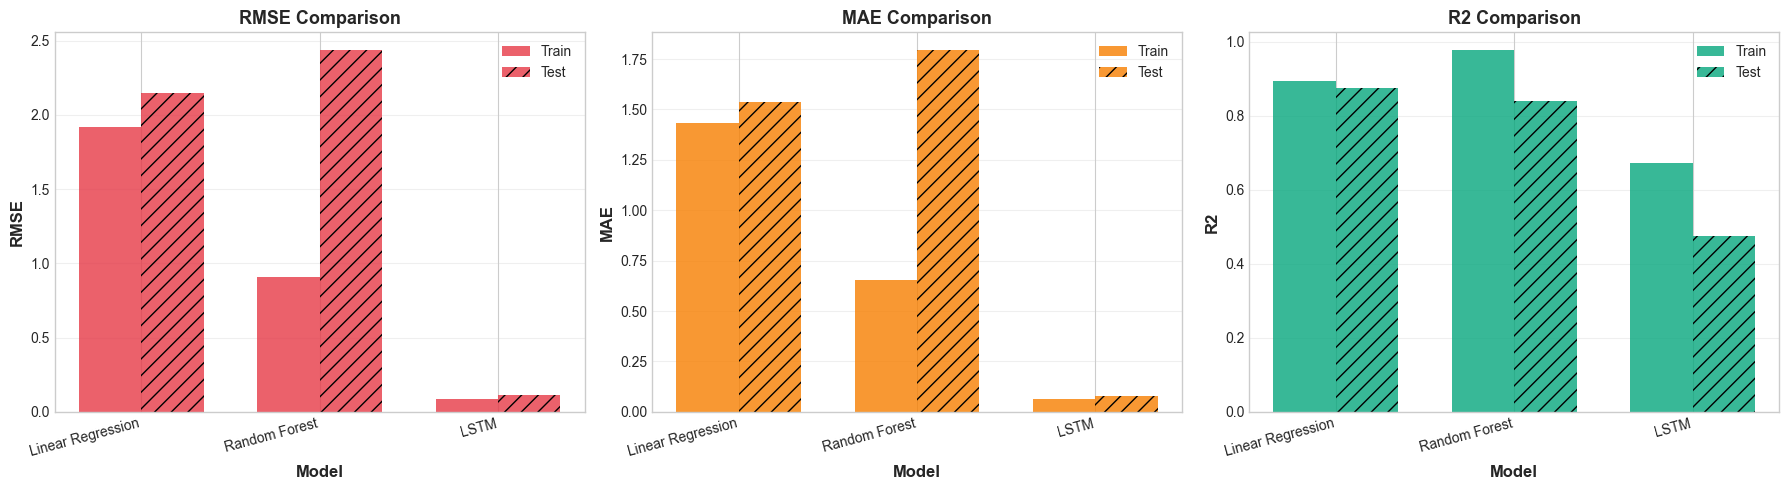

In [17]:
# Visualize model comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['RMSE', 'MAE', 'R2']
colors = ['#E63946', '#F77F00', '#06A77D']

for idx, metric in enumerate(metrics):
    train_col = f'Train_{metric}'
    test_col = f'Test_{metric}'
    
    x = np.arange(len(comparison_df))
    width = 0.35
    
    axes[idx].bar(x - width/2, comparison_df[train_col], width, label='Train', alpha=0.8, color=colors[idx])
    axes[idx].bar(x + width/2, comparison_df[test_col], width, label='Test', alpha=0.8, color=colors[idx], hatch='//')
    
    axes[idx].set_xlabel('Model', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel(metric, fontsize=12, fontweight='bold')
    axes[idx].set_title(f'{metric} Comparison', fontsize=13, fontweight='bold')
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(comparison_df['Model'], rotation=15, ha='right')
    axes[idx].legend(fontsize=10)
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 5.2 Prediction Visualizations

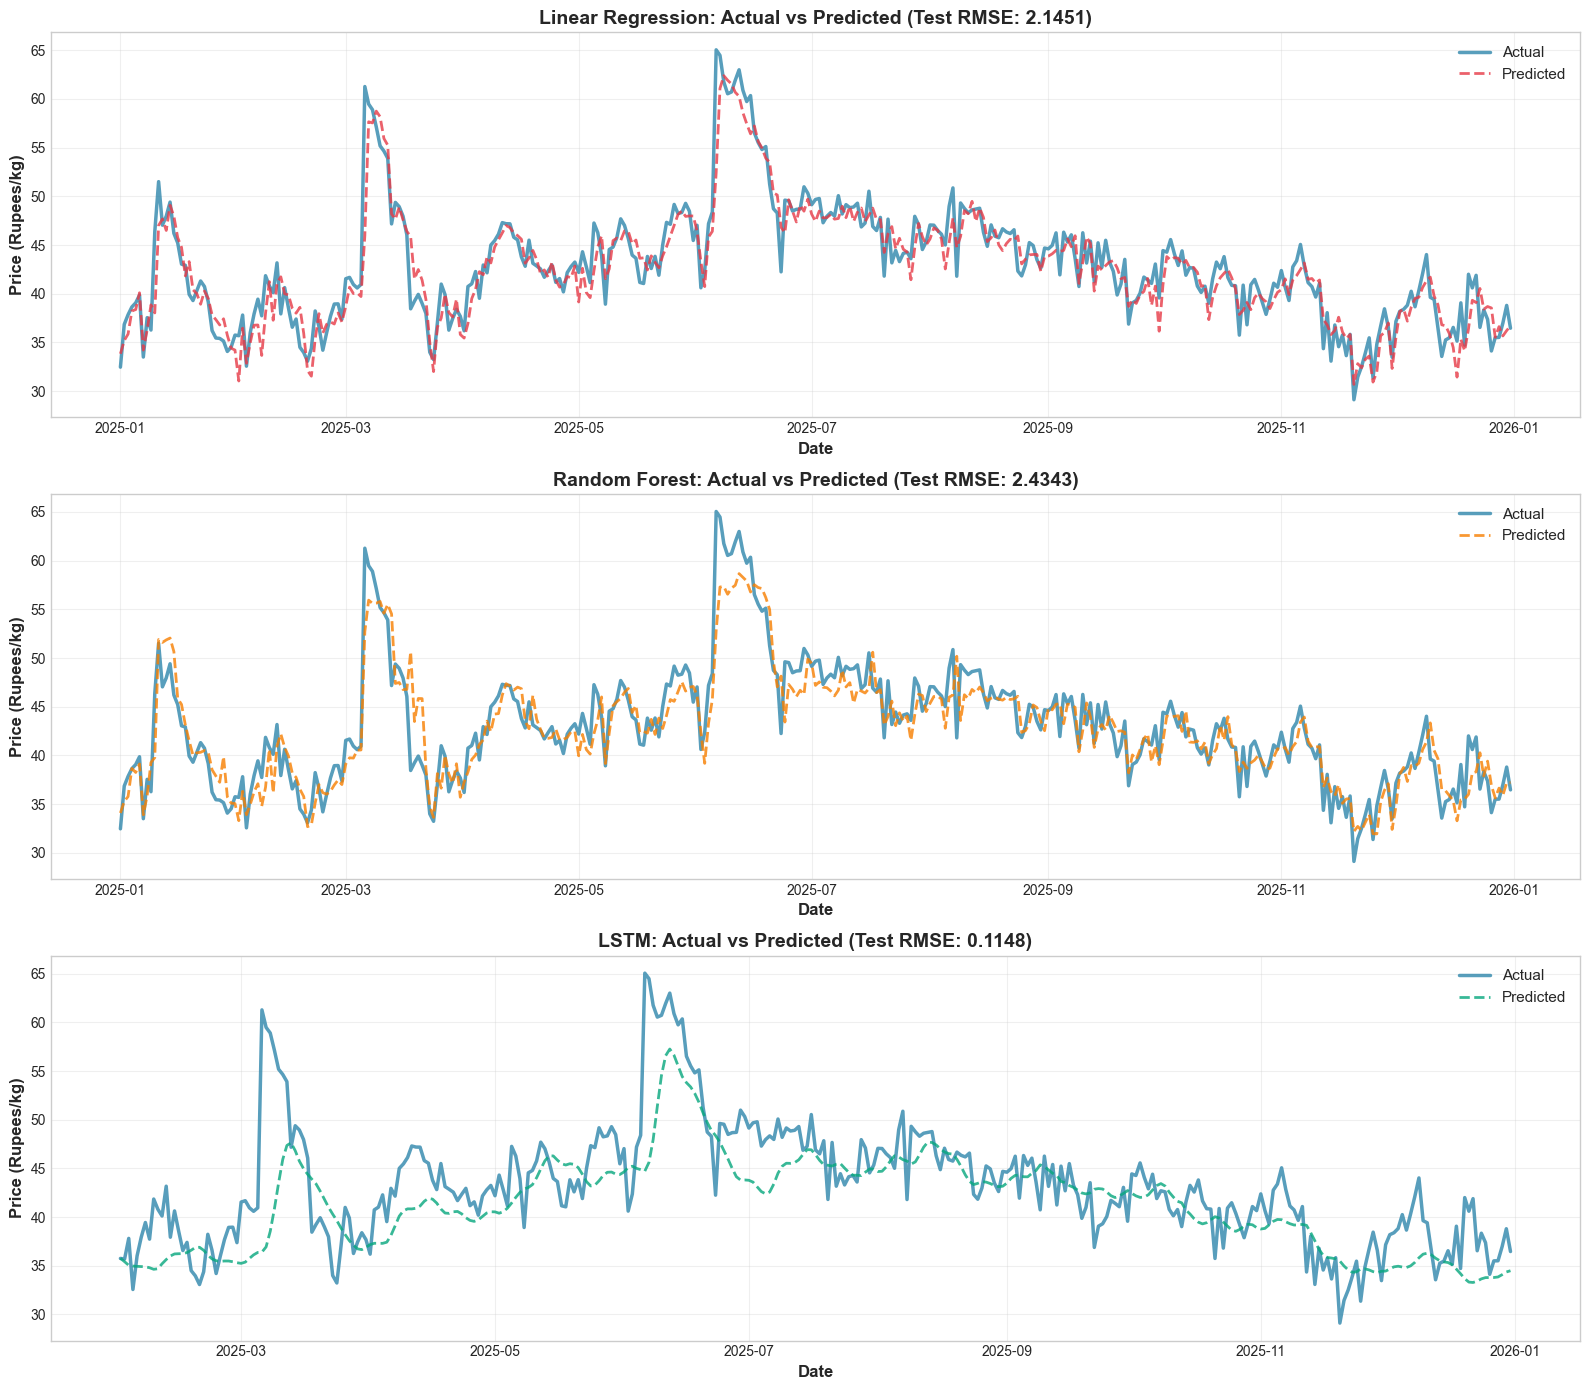

In [18]:
# Plot predictions for all models
test_dates = test_df['date'].values

fig, axes = plt.subplots(3, 1, figsize=(16, 14))

# Linear Regression
axes[0].plot(test_dates, y_test, label='Actual', linewidth=2.5, alpha=0.8, color='#2E86AB')
axes[0].plot(test_dates, y_test_pred_lr, label='Predicted', linewidth=2, alpha=0.8, color='#E63946', linestyle='--')
axes[0].set_xlabel('Date', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Price (Rupees/kg)', fontsize=12, fontweight='bold')
axes[0].set_title(f'Linear Regression: Actual vs Predicted (Test RMSE: {test_metrics_lr["RMSE"]:.4f})', 
                  fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Random Forest
axes[1].plot(test_dates, y_test, label='Actual', linewidth=2.5, alpha=0.8, color='#2E86AB')
axes[1].plot(test_dates, y_test_pred_rf, label='Predicted', linewidth=2, alpha=0.8, color='#F77F00', linestyle='--')
axes[1].set_xlabel('Date', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Price (Rupees/kg)', fontsize=12, fontweight='bold')
axes[1].set_title(f'Random Forest: Actual vs Predicted (Test RMSE: {test_metrics_rf["RMSE"]:.4f})', 
                  fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

# LSTM (adjust for sequence offset)
test_dates_lstm = test_dates[lookback:]
y_test_lstm_aligned = y_test[lookback:]
axes[2].plot(test_dates_lstm, y_test_lstm_aligned, label='Actual', linewidth=2.5, alpha=0.8, color='#2E86AB')
axes[2].plot(test_dates_lstm, y_test_pred_lstm, label='Predicted', linewidth=2, alpha=0.8, color='#06A77D', linestyle='--')
axes[2].set_xlabel('Date', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Price (Rupees/kg)', fontsize=12, fontweight='bold')
axes[2].set_title(f'LSTM: Actual vs Predicted (Test RMSE: {test_metrics_lstm["RMSE"]:.4f})', 
                  fontsize=14, fontweight='bold')
axes[2].legend(fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5.3 Residual Analysis

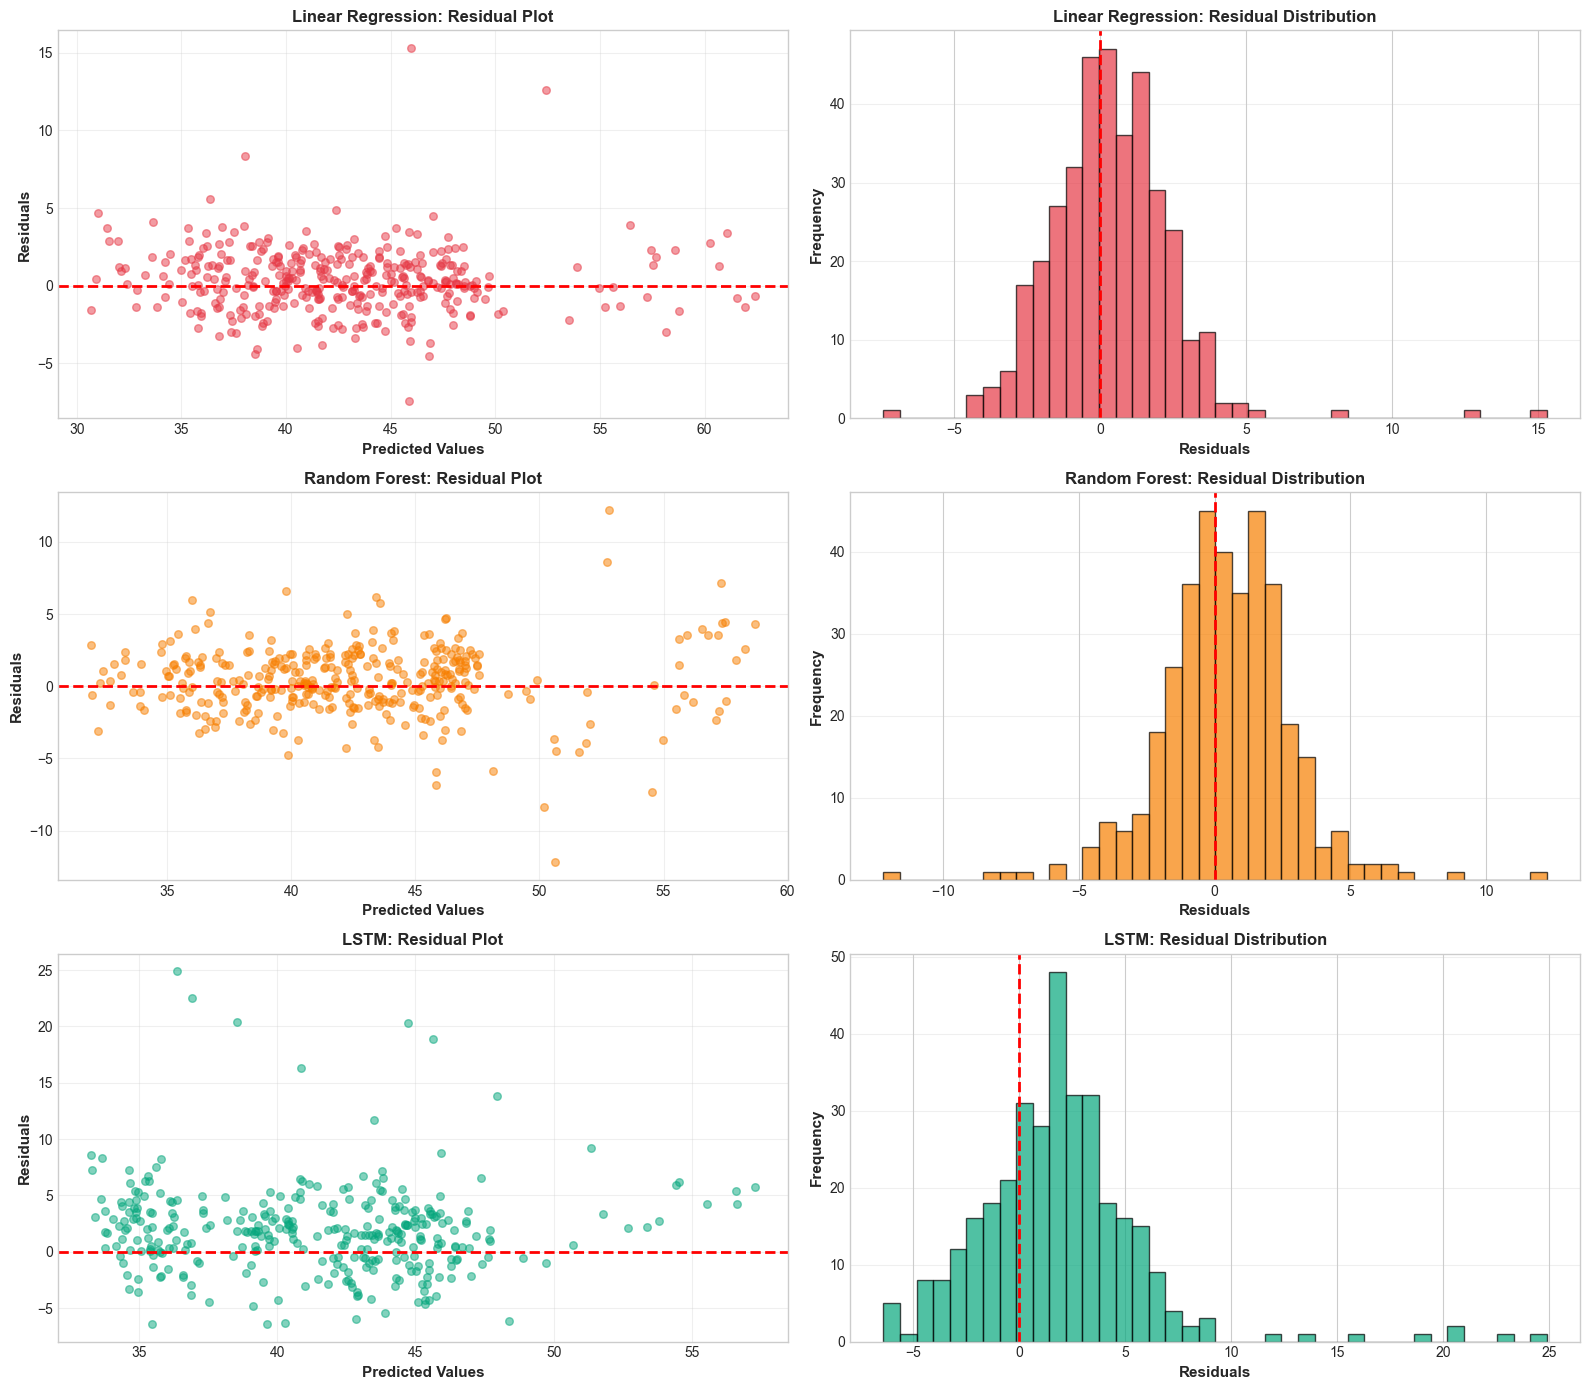

In [19]:
# Residual analysis for all models
fig, axes = plt.subplots(3, 2, figsize=(16, 14))

models_data = [
    ('Linear Regression', y_test, y_test_pred_lr, '#E63946'),
    ('Random Forest', y_test, y_test_pred_rf, '#F77F00'),
    ('LSTM', y_test_lstm_aligned, y_test_pred_lstm, '#06A77D')
]

for idx, (model_name, y_true, y_pred, color) in enumerate(models_data):
    residuals = y_true - y_pred
    
    # Residual scatter plot
    axes[idx, 0].scatter(y_pred, residuals, alpha=0.5, color=color, s=30)
    axes[idx, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[idx, 0].set_xlabel('Predicted Values', fontsize=11, fontweight='bold')
    axes[idx, 0].set_ylabel('Residuals', fontsize=11, fontweight='bold')
    axes[idx, 0].set_title(f'{model_name}: Residual Plot', fontsize=12, fontweight='bold')
    axes[idx, 0].grid(True, alpha=0.3)
    
    # Residual histogram
    axes[idx, 1].hist(residuals, bins=40, edgecolor='black', alpha=0.7, color=color)
    axes[idx, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
    axes[idx, 1].set_xlabel('Residuals', fontsize=11, fontweight='bold')
    axes[idx, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
    axes[idx, 1].set_title(f'{model_name}: Residual Distribution', fontsize=12, fontweight='bold')
    axes[idx, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 5.4 Feature Importance (Random Forest)


Top 15 Most Important Features (Random Forest):


,Feature,Importance
5,price_rupees_per_kg_rolling_mean_7,0.550235
2,price_rupees_per_kg_lag_1,0.318098
0,volume_quintals,0.043799
6,price_rupees_per_kg_rolling_std_7,0.041431
14,day_of_year_cos,0.006880
7,price_rupees_per_kg_rolling_mean_30,0.006839
8,price_rupees_per_kg_rolling_std_30,0.006234
3,price_rupees_per_kg_lag_7,0.006119
4,price_rupees_per_kg_lag_30,0.006096
13,day_of_year_sin,0.004413


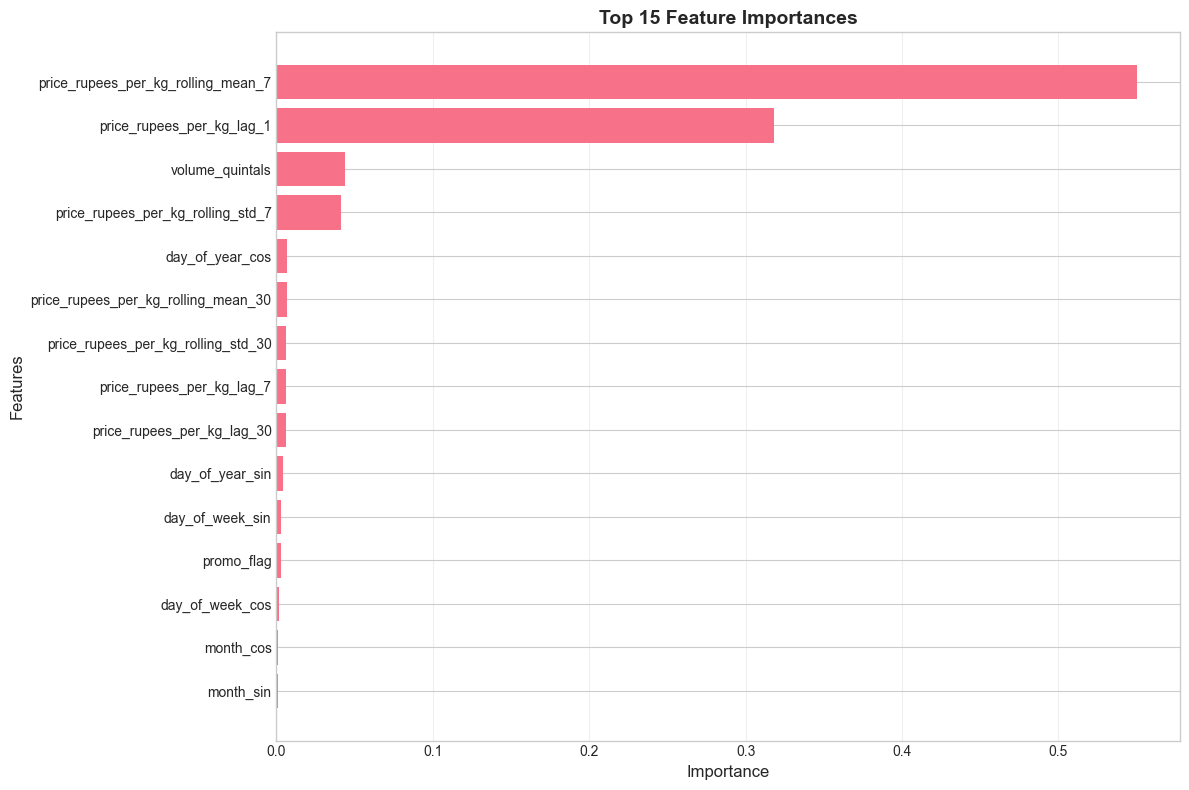

In [20]:
# Feature importance for Random Forest
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 15 Most Important Features (Random Forest):")
display(importance_df.head(15))

# Plot feature importance
fig = plot_feature_importance(rf_model, feature_cols, top_n=15, figsize=(12, 8))
plt.show()

### 5.5 Key Insights and Conclusions

#### Model Performance Summary

Based on the evaluation metrics, we can draw the following conclusions:

1. **Best Performing Model:** The model with the lowest test RMSE demonstrates the best generalization to unseen data.

2. **Linear Regression (Baseline):**
   - Provides interpretable coefficients
   - Fast training and prediction
   - May struggle with non-linear patterns
   - Useful for understanding linear trends

3. **Random Forest:**
   - Captures non-linear relationships effectively
   - Provides feature importance rankings
   - Robust to outliers
   - May overfit if not properly tuned

4. **LSTM:**
   - Excels at capturing temporal dependencies
   - Learns complex sequential patterns
   - Requires more data and computational resources
   - Best for long-term forecasting

#### Feature Importance Insights

From the Random Forest feature importance analysis:
- **Lag features** (previous prices) are typically the strongest predictors
- **Rolling statistics** capture trend and volatility information
- **Cyclical features** help model seasonal patterns
- **Volume and promotional flags** provide additional market context

#### Practical Applications

1. **For Farmers:** Use predictions to plan harvest timing and negotiate better prices
2. **For Traders:** Optimize inventory levels and pricing strategies
3. **For Policymakers:** Identify potential price spikes and implement interventions
4. **For Consumers:** Anticipate price changes for better budgeting

#### Future Improvements

1. **External Data:** Incorporate weather data, policy changes, and market indices
2. **Ensemble Methods:** Combine predictions from multiple models
3. **Hyperparameter Tuning:** Use grid search or Bayesian optimization
4. **Real-time Updates:** Implement online learning for continuous model updates
5. **Uncertainty Quantification:** Add prediction intervals for risk assessment

---

## Summary

This notebook presented a comprehensive analysis of agricultural price forecasting using machine learning and deep learning techniques. We:

1. ✅ Defined the problem and objectives for onion price forecasting
2. ✅ Loaded and explored the 2022-2025 dataset with 1,461 daily observations
3. ✅ Applied feature engineering (lag features, rolling statistics, cyclical encoding)
4. ✅ Implemented three models: Linear Regression, Random Forest, and LSTM
5. ✅ Evaluated models using RMSE, MAE, and R² metrics
6. ✅ Visualized predictions, residuals, and feature importance
7. ✅ Provided actionable insights for stakeholders

**Key Takeaway:** Machine learning and deep learning provide powerful tools for agricultural price forecasting, enabling data-driven decision-making across the agricultural value chain.

---

**Project Repository:** AI-Trend-Analyzer